**PanaceIA: Detecção de fraturas em ossos da parte superior do corpo humano**




In [ ]:
# Aqui importamos o nosso drive para acessar nosso dataset

from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os

# Caminho da pasta base
base_dir = "/content/drive/MyDrive/PanaceIA/Teste_PanaceIA"

print("🔍 Verificando caminho:", base_dir)
print("📂 Existe?", os.path.exists(base_dir))

if os.path.exists(base_dir):
    print("\n📁 Conteúdo da pasta:")
    print(os.listdir(base_dir))
else:
    print("\n❌ Caminho não encontrado. Verifique o nome exato da pasta no Meu Drive.")


In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/PanaceIA/Teste_PanaceIA"


**Validar treino da IA**

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

# Otimização
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


**Treino da IA**

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Congelar camadas pré-treinadas

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")  # 0 = normal, 1 = fratura
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3

)


In [ ]:
# Aqui salvamos o modelo de treino efetuado

model.save("/content/modelo_fraturas.h5")
print("✅ Modelo salvo com sucesso!")

**Ajustar a imagem**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

def preparar_imagem(caminho):
    img = image.load_img(caminho, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0   # normalização
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

**Finalmente, a IA está pronta para uso**

In [ ]:
from google.colab import files

uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    caminho_imagem = nome_arquivo
    print(" Imagem recebida:", caminho_imagem)

# Clique em "Choose files" e selecione uma imagem de um raio-x de osso superior do corpo humano para ser analisada

In [ ]:
# Recarrega o modelo
modelo = tf.keras.models.load_model("/content/modelo_fraturas.h5")

# Prepara a imagem
img = preparar_imagem(caminho_imagem)

# Faz predição
pred = modelo.predict(img)[0][0]

print("🔍 Resultado da IA:")
if pred > 0.5:
    print("🟥 **Fratura detectada** ")
else:
    print("🟩 **Ossos normais** ")

print(f"\nConfiança: {pred:.4f}")

# AO executar essa célula, a imagem carregada anteriormente é analisada e você obtem sua resposta

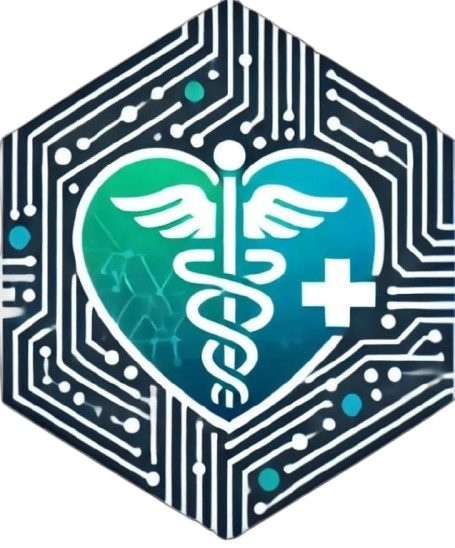
**Obrigado pela atenção!**